In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve)
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import pickle
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('/Users/naren/Projects/attrition-payroll-risk/data/processed/attrition_processed.csv')
print("Shape:", df.shape)
print("Attrition Distribution:\n", df['Attrition_Flag'].value_counts())

Shape: (1470, 48)
Attrition Distribution:
 Attrition_Flag
0    1233
1     237
Name: count, dtype: int64


#Select Features for Model

In [2]:
# All features we'll use for prediction
feature_cols = [
    # Original payroll features
    'Age', 'MonthlyIncome', 'PercentSalaryHike', 'JobLevel',
    'YearsAtCompany', 'TotalWorkingYears', 'YearsInCurrentRole',
    'YearsSinceLastPromotion', 'YearsWithCurrManager',
    'DistanceFromHome', 'NumCompaniesWorked', 'TrainingTimesLastYear',
    'WorkLifeBalance', 'JobSatisfaction', 'EnvironmentSatisfaction',
    'RelationshipSatisfaction', 'PerformanceRating', 'StockOptionLevel',

    # Our engineered payroll features
    'Compensation_Ratio', 'OverTime_Flag', 'Overtime_LowHike_Risk',
    'Tenure_Per_Level', 'Total_Comp_Score', 'Exp_Pay_Ratio',

    # Encoded categorical features
    'BusinessTravel_Enc', 'Department_Enc', 'EducationField_Enc',
    'Gender_Enc', 'JobRole_Enc', 'MaritalStatus_Enc', 'Hike_Band_Enc'
]

X = df[feature_cols]
y = df['Attrition_Flag']

print("Features shape:", X.shape)
print("Target distribution:\n", y.value_counts())

Features shape: (1470, 31)
Target distribution:
 Attrition_Flag
0    1233
1     237
Name: count, dtype: int64


In [3]:
#Handle Class Imbalance Check

In [4]:
# Attrition is always imbalanced - more 'No' than 'Yes'
total = len(y)
attrition_yes = y.sum()
attrition_no = total - attrition_yes

print(f"Total Employees : {total}")
print(f"Left (Yes)      : {attrition_yes} ({round(attrition_yes/total*100,1)}%)")
print(f"Stayed (No)     : {attrition_no} ({round(attrition_no/total*100,1)}%)")

# Calculate scale_pos_weight for XGBoost to handle imbalance
scale_pos_weight = attrition_no / attrition_yes
print(f"\nscale_pos_weight for XGBoost: {round(scale_pos_weight, 2)}")

Total Employees : 1470
Left (Yes)      : 237 (16.1%)
Stayed (No)     : 1233 (83.9%)

scale_pos_weight for XGBoost: 5.2


In [ ]:
#Train Test Split

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # maintains same attrition ratio in both sets
)

print("Training set  :", X_train.shape)
print("Test set      :", X_test.shape)
print("\nTrain attrition rate:", round(y_train.mean()*100, 1), "%")
print("Test attrition rate :", round(y_test.mean()*100, 1), "%")

Training set  : (1176, 31)
Test set      : (294, 31)

Train attrition rate: 16.2 %
Test attrition rate : 16.0 %


In [6]:
#Scale Features

In [7]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling done!")

Scaling done!


In [8]:
#Train Random Forest

In [9]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=6,
    random_state=42,
    class_weight='balanced'
)

rf_model.fit(X_train_scaled, y_train)
rf_preds = rf_model.predict(X_test_scaled)
rf_proba = rf_model.predict_proba(X_test_scaled)[:, 1]

print("=== Random Forest Results ===")
print(classification_report(y_test, rf_preds))
print("ROC AUC Score:", round(roc_auc_score(y_test, rf_proba), 4))

=== Random Forest Results ===
              precision    recall  f1-score   support

           0       0.90      0.86      0.88       247
           1       0.41      0.51      0.46        47

    accuracy                           0.81       294
   macro avg       0.66      0.69      0.67       294
weighted avg       0.82      0.81      0.81       294

ROC AUC Score: 0.7749


In [10]:
#Train XGBoost

In [11]:
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train_scaled, y_train)
xgb_preds = xgb_model.predict(X_test_scaled)
xgb_proba = xgb_model.predict_proba(X_test_scaled)[:, 1]

print("=== XGBoost Results ===")
print(classification_report(y_test, xgb_preds))
print("ROC AUC Score:", round(roc_auc_score(y_test, xgb_proba), 4))

=== XGBoost Results ===
              precision    recall  f1-score   support

           0       0.90      0.91      0.90       247
           1       0.48      0.45      0.46        47

    accuracy                           0.83       294
   macro avg       0.69      0.68      0.68       294
weighted avg       0.83      0.83      0.83       294

ROC AUC Score: 0.7761


In [12]:
#Compare Both Models

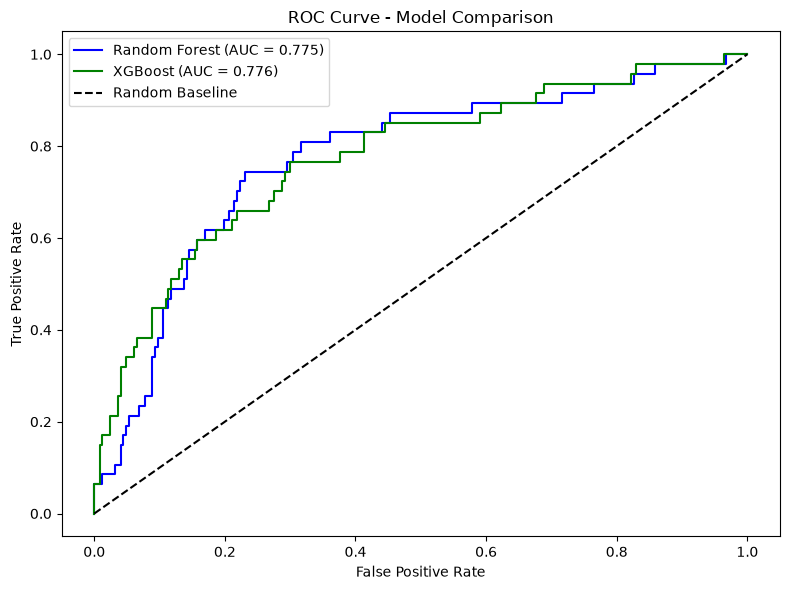


Best Model: XGBoost


In [13]:
rf_auc = roc_auc_score(y_test, rf_proba)
xgb_auc = roc_auc_score(y_test, xgb_proba)

# Plot ROC Curves
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_proba)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_proba)

plt.figure(figsize=(8,6))
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {rf_auc:.3f})', color='blue')
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {xgb_auc:.3f})', color='green')
plt.plot([0,1], [0,1], 'k--', label='Random Baseline')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Model Comparison')
plt.legend()
plt.tight_layout()
plt.show()

print(f"\nBest Model: {'XGBoost' if xgb_auc > rf_auc else 'Random Forest'}")

In [14]:
#Confusion Matrix of Best Model

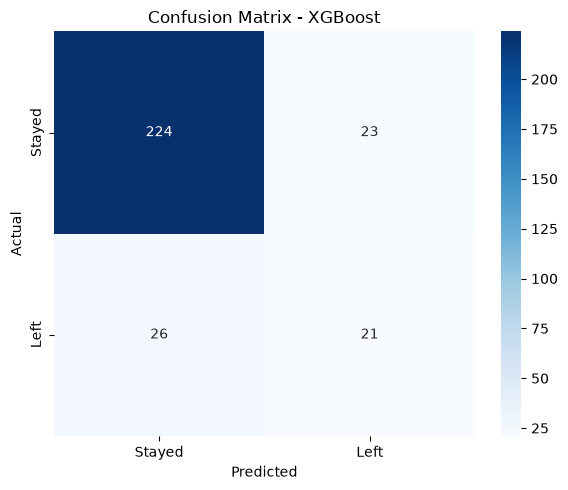

In [15]:
# Use XGBoost as final model
best_preds = xgb_preds

cm = confusion_matrix(y_test, best_preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Stayed', 'Left'],
            yticklabels=['Stayed', 'Left'])
plt.title('Confusion Matrix - XGBoost')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

In [16]:
#Feature Importance (Payroll Features)

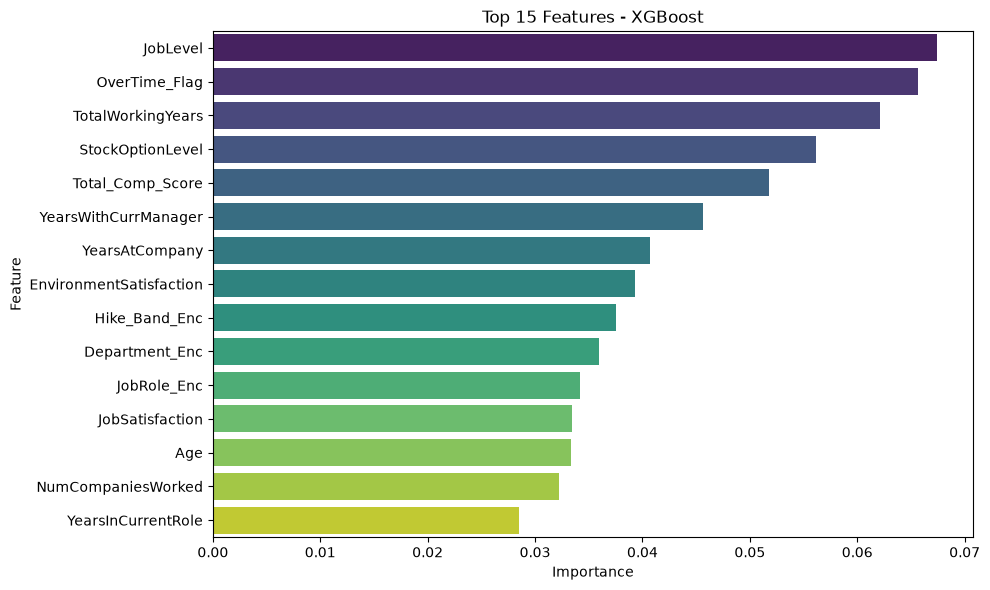

                    Feature  Importance
3                  JobLevel    0.067436
19            OverTime_Flag    0.065635
5         TotalWorkingYears    0.062093
17         StockOptionLevel    0.056199
22         Total_Comp_Score    0.051821
8      YearsWithCurrManager    0.045678
4            YearsAtCompany    0.040662
14  EnvironmentSatisfaction    0.039333
30            Hike_Band_Enc    0.037539
25           Department_Enc    0.035960
28              JobRole_Enc    0.034210
13          JobSatisfaction    0.033399
0                       Age    0.033314
10       NumCompaniesWorked    0.032193
6        YearsInCurrentRole    0.028528


In [17]:
importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=importance_df,
            hue='Feature', palette='viridis', legend=False)
plt.title('Top 15 Features - XGBoost')
plt.tight_layout()
plt.show()

print(importance_df)

In [18]:
#Save Model & Scaler

In [19]:
# Save XGBoost model
with open('/Users/naren/Projects/attrition-payroll-risk/models/attrition_model.pkl', 'wb') as f:
    pickle.dump(xgb_model, f)

# Save scaler
with open('/Users/naren/Projects/attrition-payroll-risk/models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Save feature column list
with open('/Users/naren/Projects/attrition-payroll-risk/models/feature_cols.pkl', 'wb') as f:
    pickle.dump(feature_cols, f)

print("Model, Scaler and Features saved successfully!")

Model, Scaler and Features saved successfully!
